In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load ratings data
ratings_df = pd.read_csv('../data/raw/u.data', sep='\t', header=None, names=['user_id', 'item_id', 'rating', 'timestamp'])

# Load item (movie) data
items_df = pd.read_csv('../data/raw/u.item', sep='|', header=None, encoding='latin-1',
                       names=['item_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL'] + [f'genre_{i}' for i in range(19)])

In [4]:
# Display first few rows of ratings data
print("Ratings Data:")
display(ratings_df.head())

# Display first few rows of item data
print("Item Data:")
display(items_df.head())

Ratings Data:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Item Data:


,item_id,title,release_date,video_release_date,IMDb_URL,genre_0,genre_1,genre_2,genre_3,genre_4,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
# Basic statistics for ratings data
print("Ratings Data Statistics:")
display(ratings_df.describe())

# Basic statistics for item data
print("Item Data Statistics:")
display(items_df.describe())

Ratings Data Statistics:


,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


Item Data Statistics:


,item_id,video_release_date,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
count,1682.000000,0.0,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,...,1682.00000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,841.500000,NaN,0.001189,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,...,0.01308,0.014269,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052
std,485.695893,NaN,0.034473,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,...,0.11365,0.118632,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714
min,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,421.250000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,841.500000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1261.750000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1682.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Shape of ratings data
print("Ratings Data Shape:", ratings_df.shape)

# Shape of item data
print("Item Data Shape:", items_df.shape)

Ratings Data Shape: (100000, 4)
Item Data Shape: (1682, 24)


/var/folders/qz/66lclpqs3xd3xgddt3593rb00000gn/T/ipykernel_35241/587452364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


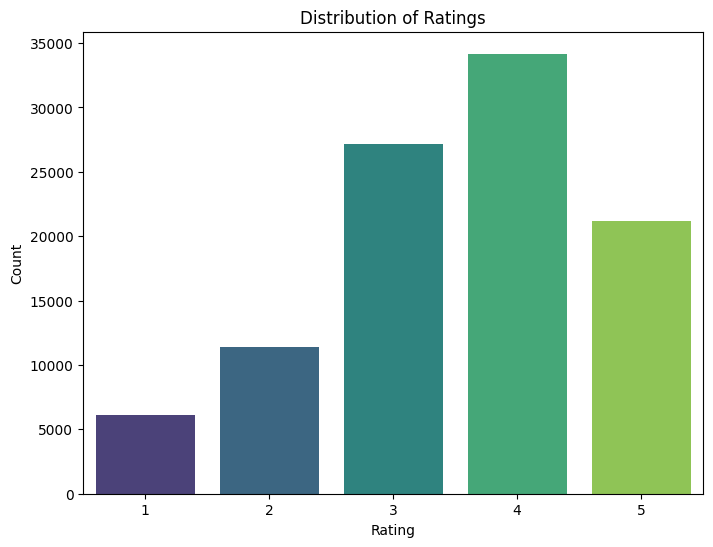

In [7]:
# Plot distribution of ratings
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

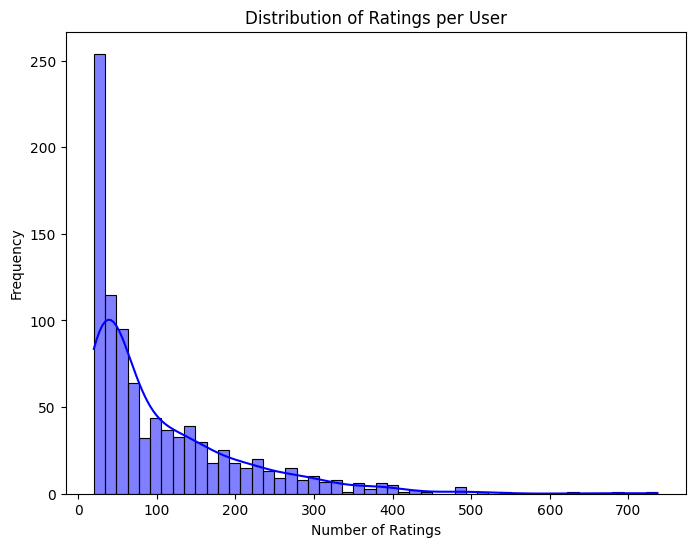

In [8]:
# Count number of ratings per user
user_ratings_count = ratings_df['user_id'].value_counts()

# Plot distribution of ratings per user
plt.figure(figsize=(8, 6))
sns.histplot(user_ratings_count, bins=50, kde=True, color='blue')
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()


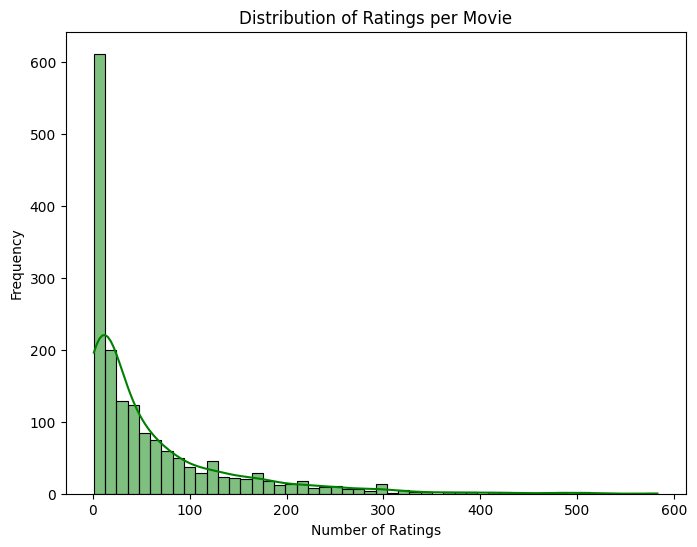

In [9]:
# Count number of ratings per movie
movie_ratings_count = ratings_df['item_id'].value_counts()

# Plot distribution of ratings per movie
plt.figure(figsize=(8, 6))
sns.histplot(movie_ratings_count, bins=50, kde=True, color='green')
plt.title('Distribution of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

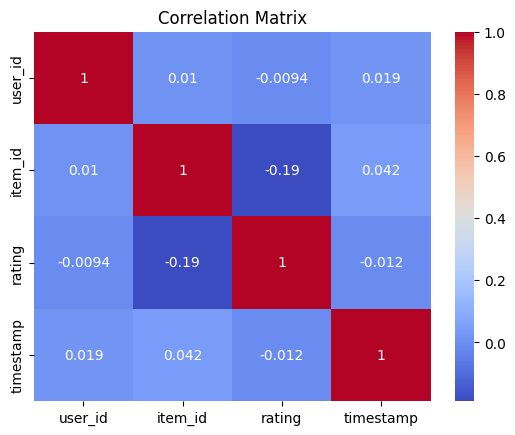

In [10]:
# Correlation matrix (if applicable)
corr_matrix = ratings_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [11]:
print("Missing Values in Ratings Data:")
print(ratings_df.isnull().sum())

print("Missing Values in Item Data:")
print(items_df.isnull().sum())

Missing Values in Ratings Data:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64
Missing Values in Item Data:
item_id                  0
title                    0
release_date             1
video_release_date    1682
IMDb_URL                 3
genre_0                  0
genre_1                  0
genre_2                  0
genre_3                  0
genre_4                  0
genre_5                  0
genre_6                  0
genre_7                  0
genre_8                  0
genre_9                  0
genre_10                 0
genre_11                 0
genre_12                 0
genre_13                 0
genre_14                 0
genre_15                 0
genre_16                 0
genre_17                 0
genre_18                 0
dtype: int64


In [12]:
# Example: Save top 10 movies by average rating
top_movies = ratings_df.groupby('item_id')['rating'].mean().sort_values(ascending=False).head(10)
top_movies.to_csv('../data/processed/top_movies.csv')

/var/folders/qz/66lclpqs3xd3xgddt3593rb00000gn/T/ipykernel_35241/3202137428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


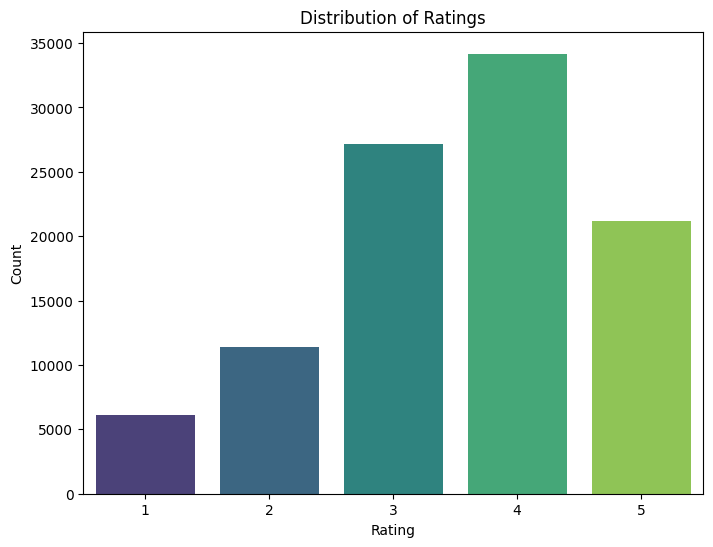

In [14]:
# Example: Save a plot
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('../experiments/results/ratings_distribution.png')
plt.show()